# EL-GHALI MOHAMED

# Régression Logistique "From Scratch" avec NumPy




In [19]:
import numpy as np

## 1. La Fonction d'Activation (Sigmoïde)

Contrairement à la régression linéaire qui prédit une valeur continue, la régression logistique doit prédire une probabilité (une valeur comprise entre 0 et 1). Pour cela, on "écrase" le résultat de notre équation linéaire en la passant dans la fonction Sigmoïde :
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

In [20]:
# 1. La Fonction Sigmoïde
def sigmoide(z):
    """
    Applique la fonction sigmoïde pour transformer les valeurs en probabilités (entre 0 et 1).
    """
    return 1 / (1 + np.exp(-z))

## 2. Entraînement et Descente de Gradient

L'algorithme met à jour les poids itérativement.
La fonction de coût utilisée ici n'est pas la MSE (comme en régression linéaire), mais l'**Entropie Croisée Binaire (Log Loss)**, adaptée aux probabilités :
$$J(\theta) = - \frac{1}{m} \sum_{i=1}^{m} [ y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) ]$$

In [21]:
# 2. Entraînement avec la Descente de Gradient
def entrainer_regression_logistique(X, y, taux_apprentissage=0.01, iterations=1000):
    # m = nombre d'exemples (lignes), n = nombre de caractéristiques (colonnes)
    m, n = X.shape

    # Initialisation des poids (theta) à zéro
    poids = np.zeros(n)

    # Liste pour stocker l'évolution de la fonction de coût
    historique_cout = []

    for i in range(iterations):
        # Étape 1: Calcul de l'hypothèse (produit scalaire suivi de la sigmoïde)
        z = np.dot(X, poids)
        predictions = sigmoide(z)

        # Étape 2: Calcul du gradient
        # Différence entre les prédictions et les vraies valeurs, multipliée par X transposé
        gradient = np.dot(X.T, (predictions - y)) / m

        # Étape 3: Mise à jour des poids
        poids -= taux_apprentissage * gradient

        # Étape 4: Calcul de la fonction de coût (Entropie croisée binaire)
        # On ajoute un très petit nombre (epsilon) pour éviter l'erreur mathématique de log(0)
        epsilon = 1e-15
        cout = -np.mean(y * np.log(predictions + epsilon) + (1 - y) * np.log(1 - predictions + epsilon))
        historique_cout.append(cout)

        # Afficher le coût toutes les 100 itérations
        if i % 100 == 0:
            print(f"Itération {i:4d} | Coût: {cout:.4f}")

    return poids, historique_cout

## 3. Fonction de Prédiction

Une fois le modèle entraîné, cette fonction prend de nouvelles données, calcule la probabilité via la sigmoïde, puis applique un seuil (généralement **0.5**) pour attribuer une classe stricte (0 ou 1).

In [22]:
# 3. Fonction de Prédiction
def predire(X, poids, seuil=0.5):
    """
    Prédit la classe (0 ou 1) en utilisant les poids entraînés.
    """
    # Calcul des probabilités
    probabilites = sigmoide(np.dot(X, poids))

    # Conversion des probabilités en classes binaires selon le seuil
    classes_predites = (probabilites >= seuil).astype(int)
    return classes_predites, probabilites

## 4. Entrainmenent du Modèle avec des Données Synthétiques

Nous allons générer deux nuages de points distincts :
* **Classe 0 :** Centrée autour des coordonnées (2, 2)
* **Classe 1 :** Centrée autour des coordonnées (7, 7)



In [23]:
# Génération d'un jeu de données synthétique (2 classes séparables)
np.random.seed(42) # Pour la reproductibilité

# Classe 0 : points centrés autour de (2, 2)
X_0 = np.random.randn(50, 2) + np.array([2, 2])
# Classe 1 : points centrés autour de (7, 7)
X_1 = np.random.randn(50, 2) + np.array([7, 7])

# Concaténation des caractéristiques (X) et création des étiquettes (y)
X_donnees = np.vstack((X_0, X_1))
y_etiquettes = np.hstack((np.zeros(50), np.ones(50)))

#  Ajout de la colonne de biais (intercept)
m = X_donnees.shape[0]
X_avec_biais = np.c_[np.ones(m), X_donnees]

print("--- Début de l'entraînement ---")
# Entraînement du modèle avec un taux d'apprentissage de 0.1
poids_finaux, couts = entrainer_regression_logistique(
    X=X_avec_biais,
    y=y_etiquettes,
    taux_apprentissage=0.1,
    iterations=500
)

print("\n--- Résultats de l'entraînement ---")
print(f"Poids finaux (biais inclus) : {poids_finaux}")

--- Début de l'entraînement ---
Itération    0 | Coût: 0.6931
Itération  100 | Coût: 0.2828
Itération  200 | Coût: 0.1808
Itération  300 | Coût: 0.1322
Itération  400 | Coût: 0.1043

--- Résultats de l'entraînement ---
Poids finaux (biais inclus) : [-4.24438199  0.60167935  0.48165063]


## 5. Visualisation avec Matplotlib



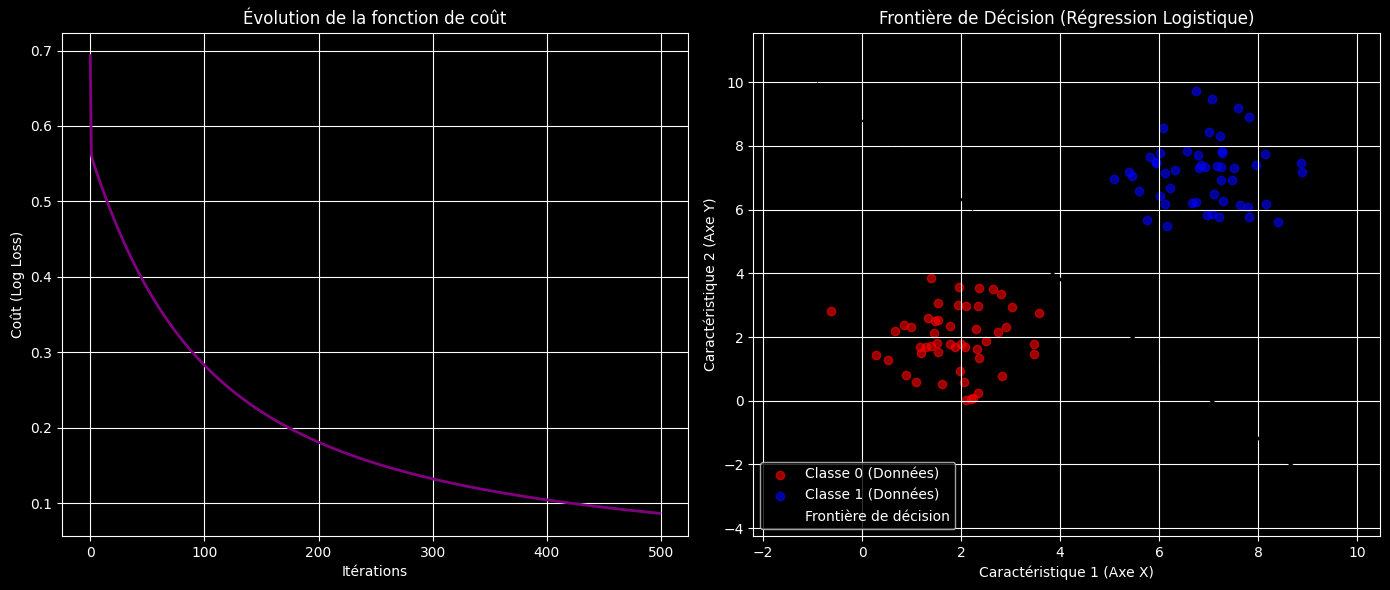

In [24]:
import matplotlib.pyplot as plt

# Création d'une figure avec deux sous-graphiques
plt.figure(figsize=(14, 6))

# ==========================================
# Graphique 1 : Courbe d'apprentissage
# ==========================================
plt.subplot(1, 2, 1)
plt.plot(couts, color='purple', linewidth=2)
plt.title("Évolution de la fonction de coût")
plt.xlabel("Itérations")
plt.ylabel("Coût (Log Loss)")
plt.grid(True)

# ==========================================
# Graphique 2 : Frontière de décision
# ==========================================
plt.subplot(1, 2, 2)

# Affichage des données d'entraînement d'origine
plt.scatter(X_0[:, 0], X_0[:, 1], color='red', label='Classe 0 (Données)', alpha=0.6)
plt.scatter(X_1[:, 0], X_1[:, 1], color='blue', label='Classe 1 (Données)', alpha=0.6)

# Calcul et tracé de la frontière de décision
# On prend les valeurs min et max de l'axe X pour tracer une ligne qui traverse tout le graphe
x1_min, x1_max = X_donnees[:, 0].min() - 1, X_donnees[:, 0].max() + 1
x1_lignes = np.array([x1_min, x1_max])

# Application de la formule mathématique pour trouver les points Y correspondants
# x2 = -(theta0 + theta1 * x1) / theta2
x2_lignes = -(poids_finaux[0] + poids_finaux[1] * x1_lignes) / poids_finaux[2]

plt.plot(x1_lignes, x2_lignes, color='black', linestyle='--', linewidth=2, label='Frontière de décision')

plt.title("Frontière de Décision (Régression Logistique)")
plt.xlabel("Caractéristique 1 (Axe X)")
plt.ylabel("Caractéristique 2 (Axe Y)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()